In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [5]:
df = pd.read_csv("downloads/Bank Customer Churn.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [7]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Check missing values in each column
print("Missing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Check for duplicate customer IDs
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())

Missing values:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Duplicate rows: 0
Duplicate customer IDs: 0


In [9]:
# Check the values in categorical and binary columns
columns_to_check = [
    "country",
    "gender",
    "credit_card",
    "active_member",
    "products_number",
    "churn"
]

for column in columns_to_check:
    print(f"\n{column}:")
    print(df[column].value_counts())


country:
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

gender:
gender
Male      5457
Female    4543
Name: count, dtype: int64

credit_card:
credit_card
1    7055
0    2945
Name: count, dtype: int64

active_member:
active_member
1    5151
0    4849
Name: count, dtype: int64

products_number:
products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

churn:
churn
0    7963
1    2037
Name: count, dtype: int64


In [10]:
# Check minimum and maximum values
numerical_columns = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "estimated_salary"
]

print(df[numerical_columns].agg(["min", "max"]))

# Count zero balances
print("\nCustomers with zero balance:",
      (df["balance"] == 0).sum())

# Check for negative numerical values
print("\nNegative values:")
print((df[numerical_columns] < 0).sum())

     credit_score  age  tenure    balance  estimated_salary
min           350   18       0       0.00             11.58
max           850   92      10  250898.09         199992.48

Customers with zero balance: 3617

Negative values:
credit_score        0
age                 0
tenure              0
balance             0
estimated_salary    0
dtype: int64


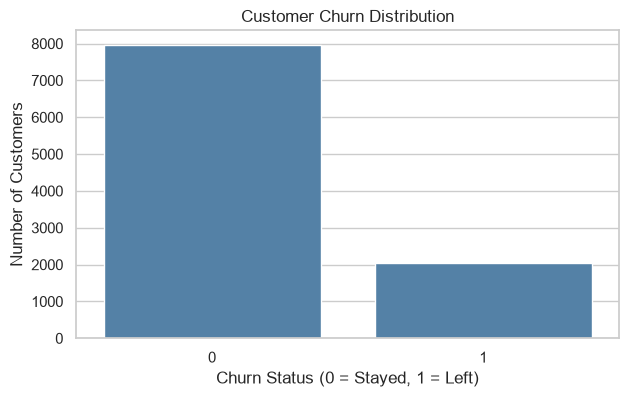

In [11]:

sns.set_theme(style="whitegrid")
# Count customers who stayed and who churned
churn_counts = df["churn"].value_counts().sort_index()

# Create a bar chart
plt.figure(figsize=(7, 4))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    color="steelblue"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Customers")

plt.show()

country
France     16.2
Germany    32.4
Spain      16.7
Name: churn, dtype: float64


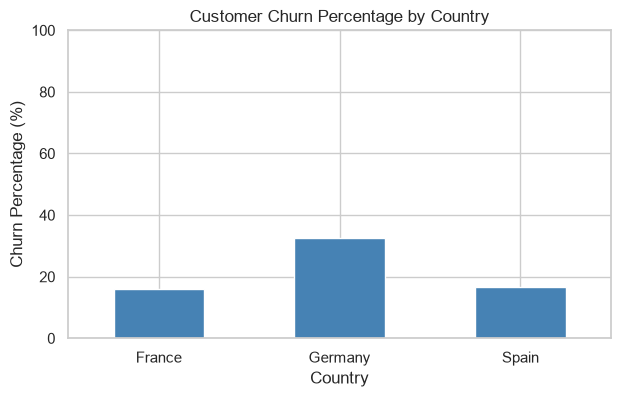

In [12]:
# Calculate churn percentage for each country
country_churn = df.groupby("country")["churn"].mean() * 100

print(country_churn.round(1))

# Create bar chart
plt.figure(figsize=(7, 4))

country_churn.plot(kind="bar", color="steelblue")

plt.title("Customer Churn Percentage by Country")
plt.xlabel("Country")
plt.ylabel("Churn Percentage (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.show()

active_member
0    26.9
1    14.3
Name: churn, dtype: float64


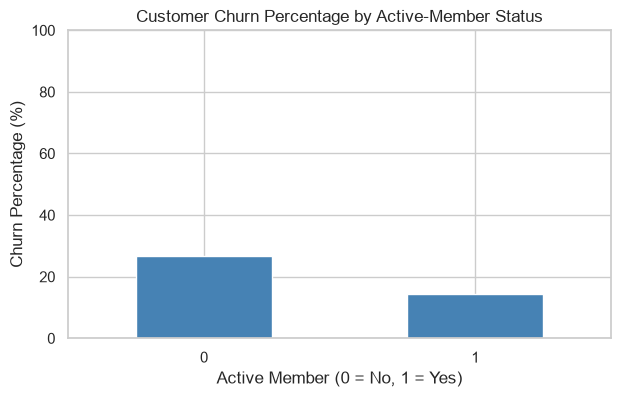

In [13]:
# Calculate churn percentage by active-member status
active_churn = df.groupby("active_member")["churn"].mean() * 100

print(active_churn.round(1))

# Create bar chart
plt.figure(figsize=(7, 4))

active_churn.plot(kind="bar", color="steelblue")

plt.title("Customer Churn Percentage by Active-Member Status")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Churn Percentage (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.show()

gender
Female    25.1
Male      16.5
Name: churn, dtype: float64


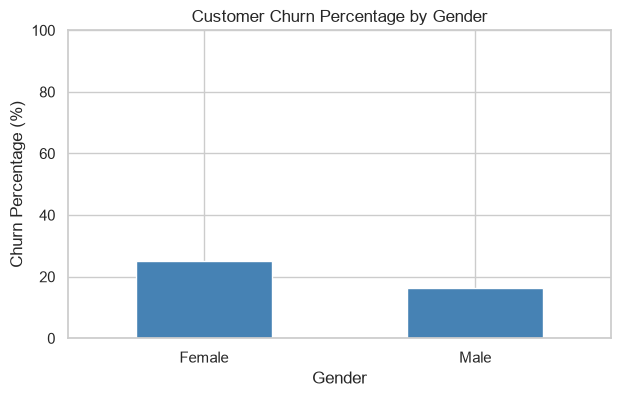

In [14]:
# Calculate churn percentage by gender
gender_churn = df.groupby("gender")["churn"].mean() * 100

print(gender_churn.round(1))

# Create bar chart
plt.figure(figsize=(7, 4))

gender_churn.plot(kind="bar", color="steelblue")

plt.title("Customer Churn Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Percentage (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.show()

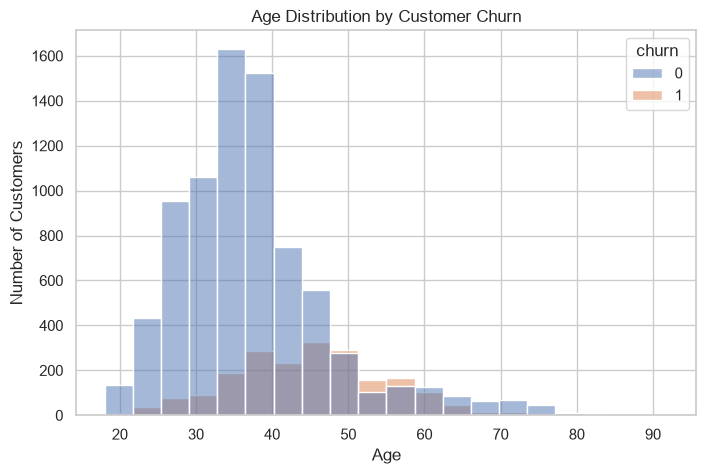

In [15]:
# Compare age distributions for customers who stayed and left
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="churn",
    bins=20,
    multiple="layer",
    alpha=0.5
)

plt.title("Age Distribution by Customer Churn")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
# Compare average and median age by churn status
age_summary = df.groupby("churn")["age"].agg(["mean", "median"])

print(age_summary.round(1))

       mean  median
churn              
0      37.4    36.0
1      44.8    45.0


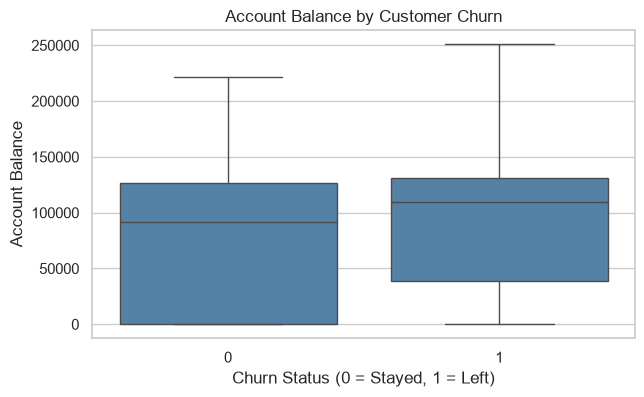

In [17]:
# Compare account balances between customers who stayed and left
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="churn",
    y="balance",
    color="steelblue"
)

plt.title("Account Balance by Customer Churn")
plt.xlabel("Churn Status (0 = Stayed, 1 = Left)")
plt.ylabel("Account Balance")

plt.show()

In [18]:
# Compare average and median account balances by churn status
balance_summary = df.groupby("churn")["balance"].agg(["mean", "median"])

print(balance_summary.round(2))

           mean     median
churn                     
0      72745.30   92072.68
1      91108.54  109349.29


products_number
1     27.7
2      7.6
3     82.7
4    100.0
Name: churn, dtype: float64


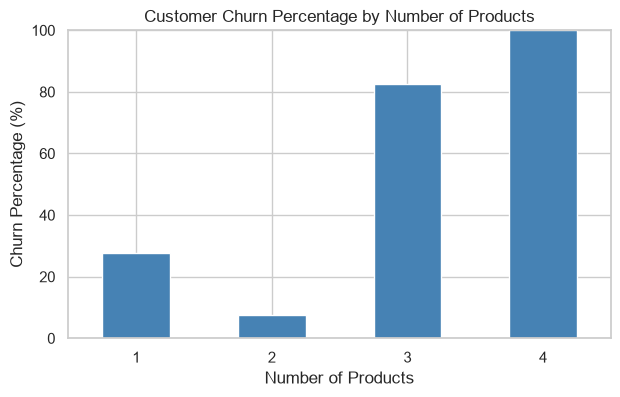

In [19]:
# Calculate churn percentage by number of products
products_churn = df.groupby("products_number")["churn"].mean() * 100

print(products_churn.round(1))

# Create bar chart
plt.figure(figsize=(7, 4))

products_churn.plot(kind="bar", color="steelblue")

plt.title("Customer Churn Percentage by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Percentage (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)

plt.show()

In [20]:
# Define predictors and target variable

X = df.drop(columns=["customer_id", "churn"])

y = df["churn"]

print("Predictors shape:", X.shape)
print("Target shape:", y.shape)

print("\nPredictor columns:")
print(X.columns.tolist())

Predictors shape: (10000, 10)
Target shape: (10000,)

Predictor columns:
['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


In [21]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the number of records in each set
print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

# Check the churn percentage in each set
print("\nTraining churn percentage:", round(y_train.mean() * 100, 2))
print("Testing churn percentage:", round(y_test.mean() * 100, 2))

Training records: 8000
Testing records: 2000

Training churn percentage: 20.38
Testing churn percentage: 20.35


In [22]:
# Identify categorical and numerical predictors

categorical_features = [
    "country",
    "gender"
]

numerical_features = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "credit_card",
    "active_member",
    "estimated_salary"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

print("\nTotal predictors:",
      len(categorical_features) + len(numerical_features))

Categorical features: ['country', 'gender']
Numerical features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

Total predictors: 10


In [23]:

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [24]:

# Create the Logistic Regression pipeline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model using training data
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [25]:
# Import model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Predict churn for the test customers
logistic_predictions = logistic_model.predict(X_test)

# Get predicted probabilities of churn
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)
logistic_auc = roc_auc_score(y_test, logistic_probabilities)

# Display results
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy:", round(logistic_accuracy, 3))
print("Precision:", round(logistic_precision, 3))
print("Recall:", round(logistic_recall, 3))
print("F1-score:", round(logistic_f1, 3))
print("ROC-AUC:", round(logistic_auc, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_predictions))

Logistic Regression Results
---------------------------
Accuracy: 0.808
Precision: 0.589
Recall: 0.187
F1-score: 0.284
ROC-AUC: 0.775

Confusion Matrix:
[[1540   53]
 [ 331   76]]


In [26]:
# Import Support Vector Machine
from sklearn.svm import SVC

# Create the SVM pipeline
svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

# Train the SVM model
svm_model.fit(X_train, y_train)

print("SVM trained successfully!")

/opt/miniconda3-pbe/envs/ana500-deep-learning/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM trained successfully!


In [27]:
# Predict churn using the SVM model
svm_predictions = svm_model.predict(X_test)

# Get predicted probabilities for ROC-AUC
svm_probabilities = svm_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)
svm_auc = roc_auc_score(y_test, svm_probabilities)

# Display SVM results
print("SVM Results")
print("-----------")
print("Accuracy:", round(svm_accuracy, 3))
print("Precision:", round(svm_precision, 3))
print("Recall:", round(svm_recall, 3))
print("F1-score:", round(svm_f1, 3))
print("ROC-AUC:", round(svm_auc, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_predictions))

SVM Results
-----------
Accuracy: 0.863
Precision: 0.855
Recall: 0.391
F1-score: 0.536
ROC-AUC: 0.825

Confusion Matrix:
[[1566   27]
 [ 248  159]]


In [28]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train the Random Forest model
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [29]:
# Predict churn using Random Forest
rf_predictions = rf_model.predict(X_test)

# Get predicted probabilities for ROC-AUC
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_auc = roc_auc_score(y_test, rf_probabilities)

# Display Random Forest results
print("Random Forest Results")
print("---------------------")
print("Accuracy:", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall:", round(rf_recall, 3))
print("F1-score:", round(rf_f1, 3))
print("ROC-AUC:", round(rf_auc, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Results
---------------------
Accuracy: 0.86
Precision: 0.77
Recall: 0.445
F1-score: 0.564
ROC-AUC: 0.848

Confusion Matrix:
[[1539   54]
 [ 226  181]]


In [30]:
# Create a comparison table for traditional ML models
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [logistic_accuracy, svm_accuracy, rf_accuracy],
    "Precision": [logistic_precision, svm_precision, rf_precision],
    "Recall": [logistic_recall, svm_recall, rf_recall],
    "F1-score": [logistic_f1, svm_f1, rf_f1],
    "ROC-AUC": [logistic_auc, svm_auc, rf_auc]
})

# Bold the highest value in each metric column
def highlight_best(column):
    if column.name == "Model":
        return [""] * len(column)

    return [
        "font-weight: bold" if value == column.max() else ""
        for value in column
    ]

# Display the formatted comparison table
model_results.style \
    .format(precision=3, subset=model_results.columns[1:]) \
    .apply(highlight_best, axis=0)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.808,0.589,0.187,0.284,0.775
1,SVM,0.863,0.855,0.391,0.536,0.825
2,Random Forest,0.860,0.770,0.445,0.564,0.848


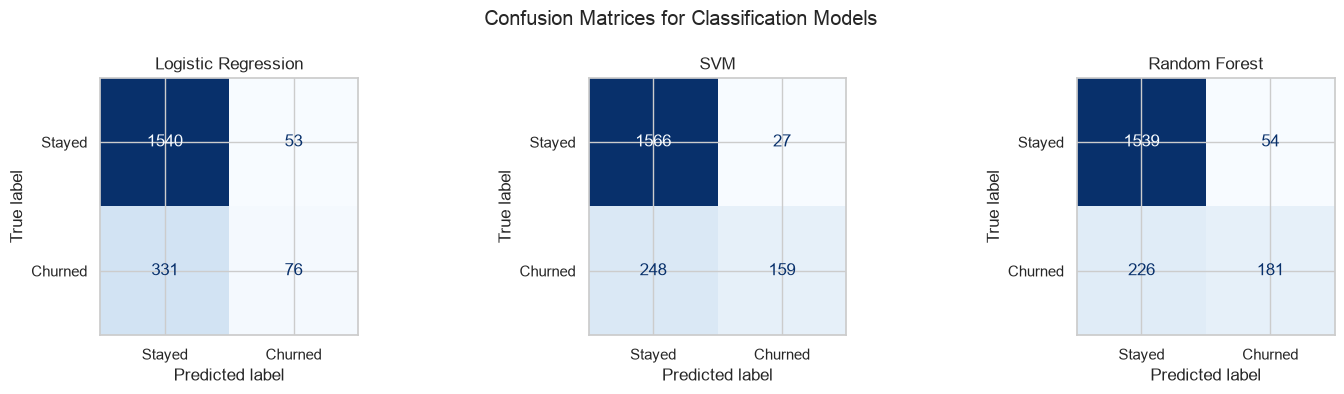

In [31]:
# Import confusion matrix display tools
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix graphs for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", logistic_predictions),
    ("SVM", svm_predictions),
    ("Random Forest", rf_predictions)
]

# Display each model's confusion matrix
for ax, (name, predictions) in zip(axes, models):

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["Stayed", "Churned"],
        cmap="Blues",
        colorbar=False,
        ax=ax
    )

    ax.set_title(name)

plt.suptitle("Confusion Matrices for Classification Models")
plt.tight_layout()
plt.show()

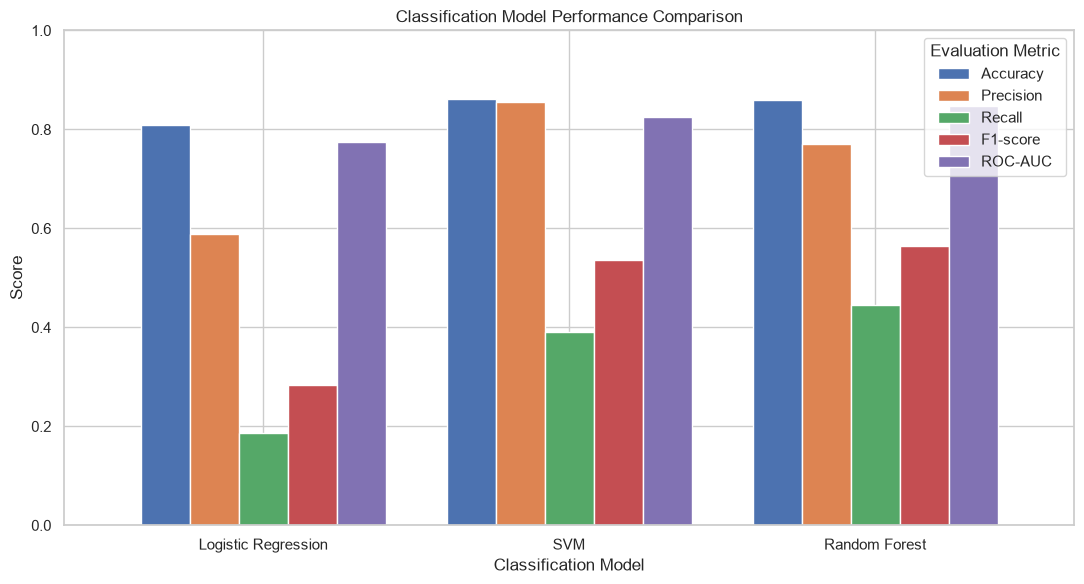

In [32]:
# Prepare the model performance data for plotting
performance_data = model_results.set_index("Model")

# Create a grouped bar chart
ax = performance_data.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.8
)

# Add chart labels
plt.title("Classification Model Performance Comparison")
plt.xlabel("Classification Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metric", loc="upper right")

# Display the chart
plt.tight_layout()
plt.show()

In [33]:
# Import TensorFlow for deep learning
import tensorflow as tf

# Display the installed TensorFlow version
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [34]:
# Check the Python version and environment
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.12.15 | packaged by Anaconda, Inc. | (main, Oct  1 2026, 20:11:32) [Clang 20.1.8 ]
Python executable: /opt/miniconda3-pbe/envs/ana500-deep-learning/bin/python


In [35]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [36]:
%pip install jinja2


Note: you may need to restart the kernel to use updated packages.


In [37]:
# Create training and validation sets for deep learning
X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Fit preprocessing using neural-network training data only
from sklearn.base import clone

nn_preprocessor = clone(preprocessor)

X_nn_train_scaled = nn_preprocessor.fit_transform(X_nn_train)
X_nn_val_scaled = nn_preprocessor.transform(X_nn_val)
X_nn_test_scaled = nn_preprocessor.transform(X_test)

# Convert to numerical arrays for TensorFlow
X_nn_train_scaled = np.asarray(X_nn_train_scaled, dtype=np.float32)
X_nn_val_scaled = np.asarray(X_nn_val_scaled, dtype=np.float32)
X_nn_test_scaled = np.asarray(X_nn_test_scaled, dtype=np.float32)

# Display shapes
print("Neural network training:", X_nn_train_scaled.shape)
print("Neural network validation:", X_nn_val_scaled.shape)
print("Neural network testing:", X_nn_test_scaled.shape)

Neural network training: (6400, 13)
Neural network validation: (1600, 13)
Neural network testing: (2000, 13)


In [38]:
# Import neural network tools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

# Set random seed for reproducibility
tf.keras.utils.set_random_seed(42)

# Create the neural network
nn_model = Sequential([
    Input(shape=(X_nn_train_scaled.shape[1],)),

    # First hidden layer
    Dense(32, activation="relu"),

    # Second hidden layer
    Dense(16, activation="relu"),

    # Dropout helps reduce overfitting
    Dropout(0.2),

    # Output layer for binary classification
    Dense(1, activation="sigmoid")
])

# Configure the model for training
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display the neural network structure
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Train the Neural Network

from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train the neural network
history = nn_model.fit(
    X_nn_train_scaled,
    y_nn_train,
    validation_data=(X_nn_val_scaled, y_nn_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Display how many epochs were completed
print("Training completed!")
print("Epochs completed:", len(history.history["loss"]))

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 916us/step - accuracy: 0.7450 - loss: 0.5327 - val_accuracy: 0.8000 - val_loss: 0.4407
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 433us/step - accuracy: 0.8141 - loss: 0.4289 - val_accuracy: 0.8269 - val_loss: 0.4109
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - accuracy: 0.8348 - loss: 0.3997 - val_accuracy: 0.8419 - val_loss: 0.3864
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - accuracy: 0.8472 - loss: 0.3791 - val_accuracy: 0.8481 - val_loss: 0.3724
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.8462 - loss: 0.3722 - val_accuracy: 0.8531 - val_loss: 0.3617
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - accuracy: 0.8508 - loss: 0.3658 - val_accuracy: 0.8544 - val_loss: 0.3578
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - accuracy: 0.8533 - loss: 0.3592 - val_accuracy: 0.8550 - val_loss: 0.3555
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.8552 - loss: 0.3539 - 

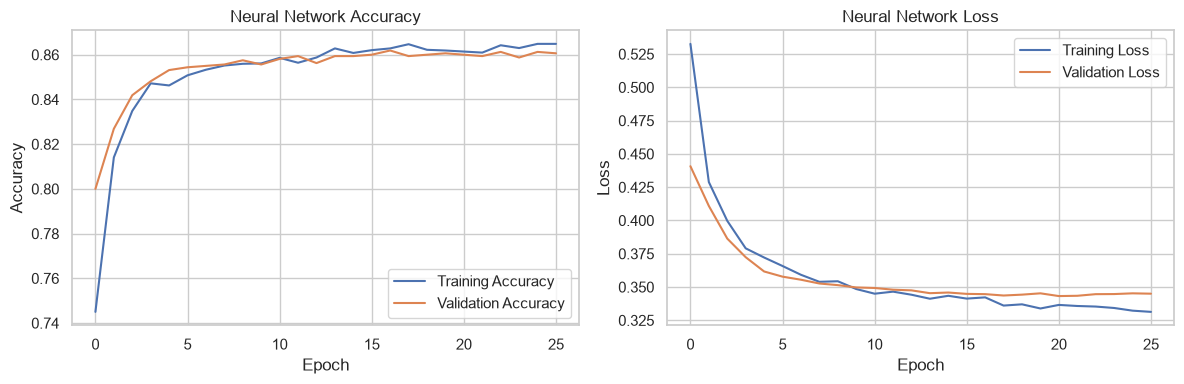

In [40]:
# Visualize Neural Network Training

# Create two graphs side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Training and validation accuracy
axes[0].plot(history.history["accuracy"], label="Training Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Neural Network Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Graph 2: Training and validation loss
axes[1].plot(history.history["loss"], label="Training Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Neural Network Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [41]:
# Evaluate the Neural Network

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Predict the probability that each customer will churn
nn_probabilities = nn_model.predict(X_nn_test_scaled).ravel()

# Convert probabilities into predictions (0 = Stay, 1 = Churn)
nn_predictions = (nn_probabilities >= 0.5).astype(int)

# Calculate evaluation metrics
nn_accuracy = accuracy_score(y_test, nn_predictions)
nn_precision = precision_score(y_test, nn_predictions, zero_division=0)
nn_recall = recall_score(y_test, nn_predictions, zero_division=0)
nn_f1 = f1_score(y_test, nn_predictions, zero_division=0)
nn_roc_auc = roc_auc_score(y_test, nn_probabilities)

# Display results
print("Neural Network Test Results")
print("---------------------------")
print(f"Accuracy:  {nn_accuracy:.3f}")
print(f"Precision: {nn_precision:.3f}")
print(f"Recall:    {nn_recall:.3f}")
print(f"F1-score:  {nn_f1:.3f}")
print(f"ROC-AUC:   {nn_roc_auc:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nn_predictions))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step
Neural Network Test Results
---------------------------
Accuracy:  0.870
Precision: 0.820
Recall:    0.459
F1-score:  0.589
ROC-AUC:   0.860

Confusion Matrix:
[[1552   41]
 [ 220  187]]


In [42]:
# Compare All Four Models

# Add the Neural Network results
nn_result = pd.DataFrame([{
    "Model": "Neural Network",
    "Accuracy": nn_accuracy,
    "Precision": nn_precision,
    "Recall": nn_recall,
    "F1-score": nn_f1,
    "ROC-AUC": nn_roc_auc
}])

# Combine traditional ML and deep learning results
all_model_results = pd.concat(
    [model_results, nn_result],
    ignore_index=True
)

# Display the comparison table with best scores in bold
all_model_results.style.format(
    precision=3,
    subset=all_model_results.columns[1:]
).apply(highlight_best, axis=0)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.808,0.589,0.187,0.284,0.775
1,SVM,0.863,0.855,0.391,0.536,0.825
2,Random Forest,0.860,0.770,0.445,0.564,0.848
3,Neural Network,0.870,0.820,0.459,0.589,0.860


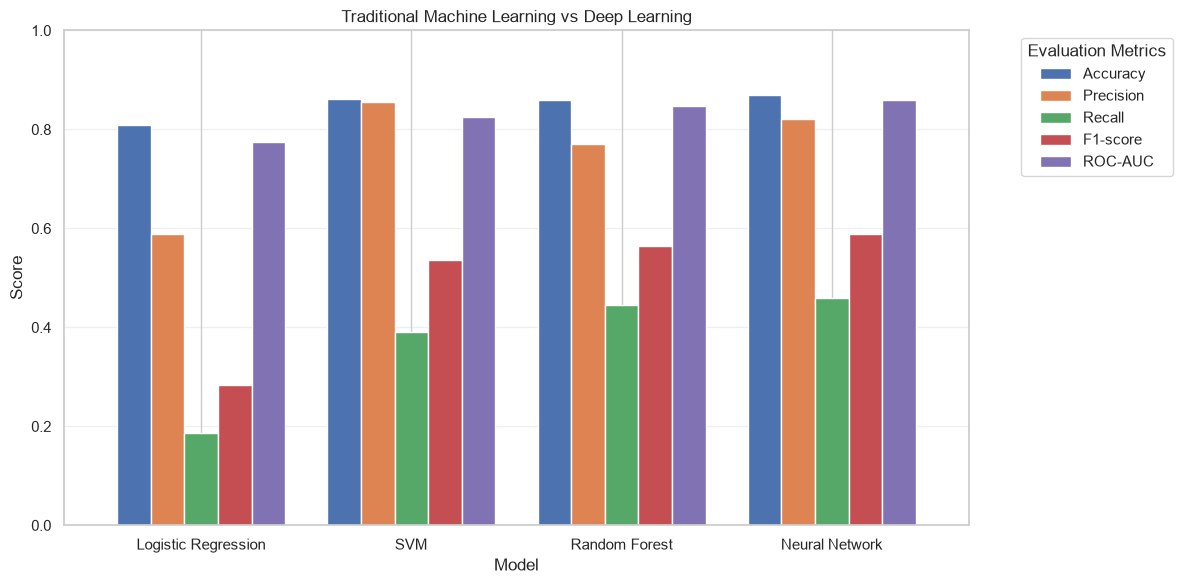

In [43]:
# Compare Traditional ML and Deep Learning

# Select the evaluation metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

# Create a grouped bar chart
ax = all_model_results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

# Add labels and title
plt.title("Traditional Machine Learning vs Deep Learning")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Evaluation Metrics", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

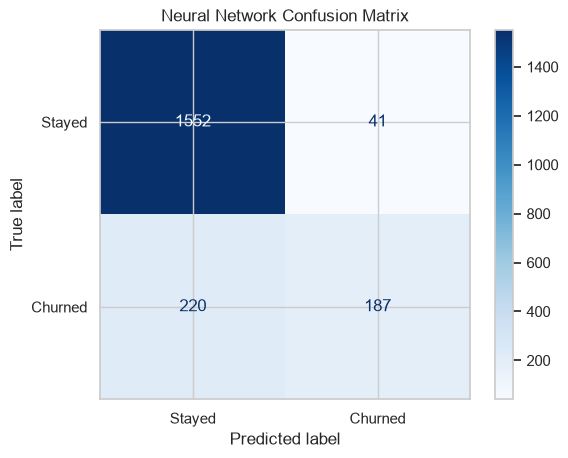

In [44]:
# Neural Network Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

# Display the neural network confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nn_predictions,
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    values_format="d"
)

plt.title("Neural Network Confusion Matrix")
plt.show()

## Final Report and Recommendations

### Project Objective
The objective of this project was to predict whether a bank customer
would leave the bank (churn) using customer information and compare
traditional machine-learning models with a deep-learning model.

### Key Findings
- The dataset contained 10,000 customers, with approximately 20.4%
  classified as churned.
- Exploratory analysis showed higher churn rates among customers in
  Germany, inactive customers, and older customers.
- Four classification models were evaluated: Logistic Regression,
  SVM, Random Forest, and an Artificial Neural Network.
- The Neural Network achieved the highest accuracy (87.0%),
  F1-score (0.589), and ROC-AUC (0.860).
- However, the Neural Network identified only 187 of the 407
  customers who actually churned.

### Recommendations
The bank could use the model to help identify customers who may be
at risk of leaving and prioritize them for further review or
customer-retention outreach.

The bank should also investigate factors associated with churn,
including customer activity, age, and geographic differences.
These associations do not establish causation.

Before using the model in real business decisions, the bank should
work to improve recall, evaluate potential bias, and test the model
on new customer data.

### Conclusion
The Neural Network performed slightly better overall than the
traditional machine-learning models in this project. However,
its relatively low recall shows that further improvements are
needed before it could be relied on for customer-retention decisions.